Name : Tanmay Sharma

Student ID: IITP_AIML_2506448

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve

In [ ]:
df = pd.read_csv("german_credit_data.csv")

In [ ]:
# Target Encoding

df['Risk'] = df['Risk'].map({'good': 0, 'bad': 1})
df['Risk'].value_counts()

,count
Risk,
0,604
1,396


In [ ]:
df.select_dtypes(include='object').columns

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose'], dtype='object')

In [ ]:
# Applying one-hot encoding to categorical variables

df = pd.get_dummies(df, drop_first=True)
df.head()

,Age,Job,Credit amount,Duration,Risk,Sex_male,Housing_own,Housing_rent,Saving accounts_moderate,Saving accounts_quite rich,Saving accounts_rich,Checking account_moderate,Checking account_rich,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
0,56,1,6745,22,0,True,True,False,False,False,False,True,False,True,False,False,False,False,False,False
1,69,2,10437,70,0,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False
2,46,3,9763,8,0,True,True,False,False,True,False,False,False,True,False,False,False,False,False,False
3,32,1,18964,70,1,False,True,False,True,False,False,False,False,False,False,False,False,True,False,False
4,60,2,17650,14,0,True,True,False,True,False,False,False,False,False,True,False,False,False,False,False


In [ ]:
# train test split

from sklearn.model_selection import train_test_split

X = df.drop('Risk', axis=1)
y = df['Risk']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y)

In [ ]:
# Scaling

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# 2.1 a) Logistic Regression

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42))
])
lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', LogisticRegression(random_state=42))])

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

y_pred = lr_pipeline.predict(X_test)
y_proba = lr_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Logistic Regression Accuracy: 0.8
ROC-AUC: 0.8978972695888692

Confusion Matrix:
 [[104  17]
 [ 23  56]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.86      0.84       121
           1       0.77      0.71      0.74        79

    accuracy                           0.80       200
   macro avg       0.79      0.78      0.79       200
weighted avg       0.80      0.80      0.80       200



In [ ]:
# Decision Tree

from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.745
ROC-AUC: 0.7255466052934407

Confusion Matrix:
 [[99 22]
 [29 50]]

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.82      0.80       121
           1       0.69      0.63      0.66        79

    accuracy                           0.74       200
   macro avg       0.73      0.73      0.73       200
weighted avg       0.74      0.74      0.74       200



In [ ]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, f1_score

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("Baseline F1 Score:", f1_score(y_test, y_pred_rf))


Random Forest Accuracy: 0.825
ROC-AUC: 0.9200230149597238

Confusion Matrix:
 [[111  10]
 [ 25  54]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.92      0.86       121
           1       0.84      0.68      0.76        79

    accuracy                           0.82       200
   macro avg       0.83      0.80      0.81       200
weighted avg       0.83      0.82      0.82       200

Baseline F1 Score: 0.7552447552447552


In [ ]:
# XGBoost

from xgboost import XGBClassifier
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, f1_score

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))
print("Baseline F1 Score:", f1_score(y_test, y_pred_xgb))

XGBoost Accuracy: 0.84
ROC-AUC: 0.9366042473062035

Confusion Matrix:
 [[108  13]
 [ 19  60]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87       121
           1       0.82      0.76      0.79        79

    accuracy                           0.84       200
   macro avg       0.84      0.83      0.83       200
weighted avg       0.84      0.84      0.84       200

Baseline F1 Score: 0.7894736842105263


In [ ]:
# 2.2 Hyperparameter Tuning
# GridSearch (Random Forest)

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)
print(f"Best params: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.4f}")

# Tuning

best_rf = grid_search.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test)
print("F1:", f1_score(y_test, y_pred))
print("F1 (Tuned):", f1_score(y_test, y_pred_rf_tuned))




Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
Best CV score: 0.8284
F1: 0.7368421052631579
F1 (Tuned): 0.7397260273972602


In [ ]:
# GridSearch (Logistic Regression)

param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l2'],
    'classifier__solver': ['liblinear', 'lbfgs']
}

grid_lr = GridSearchCV(
    lr_pipeline, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1
)

grid_lr.fit(X_train, y_train)

print("Best Parameters:", grid_lr.best_params_)
print("Best F1 Score:", grid_lr.best_score_)

# Tuning

best_lr = grid_lr.best_estimator_

y_pred_lr_tuned = best_lr.predict(X_test)
print("F1:", f1_score(y_test, y_pred))
print("F1 (Tuned):", f1_score(y_test, y_pred_lr_tuned))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'classifier__C': 100, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Best F1 Score: 0.7546720382887183
F1: 0.7368421052631579
F1 (Tuned): 0.7532467532467533


In [ ]:
# GridSearch (XGBoost)

from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

param_grid = {
    "n_estimators": [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.1],
}
grid_search_xgb = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid, cv=5, scoring='f1', n_jobs=-1,verbose=1)

grid_search_xgb.fit(X_train, y_train)

print("Best XGBoost params:", grid_search_xgb.best_params_)
print("Best XGBoost F1 score:", grid_search_xgb.best_score_)

# Tuning

best_xgb = grid_search_xgb.best_estimator_
y_pred_xgb_tuned = best_xgb.predict(X_test)

print("F1:", f1_score(y_test, y_pred_xgb))
print("F1 (Tuned):", f1_score(y_test, y_pred_xgb_tuned))

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best XGBoost params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Best XGBoost F1 score: 0.8334899479814173
F1: 0.7894736842105263
F1 (Tuned): 0.7945205479452054


In [ ]:
!pip install mlflow

In [ ]:
# Random Forest

import mlflow
import mlflow.sklearn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

mlflow.set_experiment("credit_risk_classification")

best_rf = grid_search.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_rf_tuned)
precision = precision_score(y_test, y_pred_rf_tuned)
recall = recall_score(y_test, y_pred_rf_tuned)
f1 = f1_score(y_test, y_pred_rf_tuned)

with mlflow.start_run(run_name="random_forest_tuned"):

  for param, value in grid_search.best_params_.items():
    mlflow.log_param(param, value)
    mlflow.log_param("model_type", "Random Forest")
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    # confusion matrix

    cm_rf = confusion_matrix(y_test, y_pred_rf_tuned)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix - Random Forest')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.savefig('cm_rf.png')
    plt.close()
    mlflow.log_artifact('cm_rf.png')
    # log model
    mlflow.sklearn.log_model(best_rf, "model")

2026/02/25 18:17:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/25 18:17:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/02/25 18:17:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/25 18:17:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

In [ ]:
# Logistic Regression

import mlflow
import mlflow.sklearn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

mlflow.set_experiment("credit_risk_classification")

best_lr = grid_lr.best_estimator_
y_pred_lr_tuned = best_lr.predict(X_test)

accuracy_lr = accuracy_score(y_test, y_pred_lr_tuned)
precision_lr = precision_score(y_test, y_pred_lr_tuned)
recall_lr = recall_score(y_test, y_pred_lr_tuned)
f1_lr = f1_score(y_test, y_pred_lr_tuned)

with mlflow.start_run(run_name="logistic_regression_tuned"):

  for param, value in grid_lr.best_params_.items():
    mlflow.log_param(param, value)
    mlflow.log_param("model_type", "Logistic Regression")
    mlflow.log_metric("accuracy", accuracy_lr)
    mlflow.log_metric("precision", precision_lr)
    mlflow.log_metric("recall", recall_lr)
    mlflow.log_metric("f1_score", f1_lr)
    #confusion matrix
    cm_lr = confusion_matrix(y_test, y_pred_lr_tuned)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix - Logistic Regression Tuned')
    plt.xlabel('Predicted')
    plt.ylabel("Actual")
    plt.savefig('cm_logistic.png')
    plt.close()
    mlflow.log_artifact('cm_logistic.png')
    #log model
    mlflow.sklearn.log_model(best_lr, "model")


2026/02/25 18:18:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/25 18:18:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/02/25 18:18:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/25 18:18:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

In [ ]:
# XGBoost

import mlflow
import mlflow.sklearn

best_xgb = grid_search_xgb.best_estimator_

y_pred_xgb_tuned = best_xgb.predict(X_test)

accuracy_xgb = accuracy_score(y_test, y_pred_xgb_tuned)
precision_xgb = precision_score(y_test, y_pred_xgb_tuned)
recall_xgb = recall_score(y_test, y_pred_xgb_tuned)
f1_xgb = f1_score(y_test, y_pred_xgb_tuned)

with mlflow.start_run(run_name="xgboost_tuned"):

  for param, value in grid_search_xgb.best_params_.items():
    mlflow.log_param(param, value)

    mlflow.log_param("model_type", "XGBoost")

    mlflow.log_metric("accuracy", accuracy_xgb)
    mlflow.log_metric("precision", precision_xgb)
    mlflow.log_metric("recall", recall_xgb)
    mlflow.log_metric("f1_score", f1_xgb)
   # confusion matrix
    cm = confusion_matrix(y_test, y_pred_xgb_tuned)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix - XGBoost Tuned')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.savefig('confusion _matrix.png')
    mlflow.log_artifact('confusion _matrix.png')
    plt.close()

     # log model
    mlflow.sklearn.log_model(best_xgb, "xgboost_model")


2026/02/25 18:18:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/25 18:18:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/02/25 18:18:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/25 18:18:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

In [ ]:
# MODEL EVALUATION AND COMPARISON

In [ ]:
# 3.1 Metrics for every model

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "AUC-ROC": roc_auc_score(y_test, y_proba)
    }

    return metrics

dt_metrics = evaluate_model(dt_model, X_test, y_test)
lr_metrics  = evaluate_model(lr_pipeline, X_test, y_test)
rf_metrics  = evaluate_model(rf_model, X_test, y_test)
xgb_metrics = evaluate_model(xgb_model, X_test, y_test)

print("Decision Tree Metrics:", dt_metrics)
print("Logistic Regression Metrics:", lr_metrics)
print("Random Forest Metrics:", rf_metrics)
print("XGBoost Metrics:", xgb_metrics)

Decision Tree Metrics: {'Accuracy': 0.745, 'Precision': 0.6944444444444444, 'Recall': 0.6329113924050633, 'F1-Score': 0.6622516556291391, 'AUC-ROC': np.float64(0.7255466052934407)}
Logistic Regression Metrics: {'Accuracy': 0.8, 'Precision': 0.7671232876712328, 'Recall': 0.7088607594936709, 'F1-Score': 0.7368421052631579, 'AUC-ROC': np.float64(0.8978972695888692)}
Random Forest Metrics: {'Accuracy': 0.825, 'Precision': 0.84375, 'Recall': 0.6835443037974683, 'F1-Score': 0.7552447552447552, 'AUC-ROC': np.float64(0.9200230149597238)}
XGBoost Metrics: {'Accuracy': 0.84, 'Precision': 0.821917808219178, 'Recall': 0.759493670886076, 'F1-Score': 0.7894736842105263, 'AUC-ROC': np.float64(0.9366042473062035)}


In [ ]:
#3.2 1. Summary comparison table

rows = []
models = {
    'Logistic Regression': lr_pipeline,
    'Random Forest': rf_model,
    'XGBoost': xgb_model
}

for name, model in models.items():
  y_pred = model.predict(X_test)
  y_proba = model.predict_proba(X_test)[:, 1]

  rows.append({
      "Model": name,
      "Accuracy": accuracy_score(y_test, y_pred),
      "Precision": precision_score(y_test, y_pred),
      "Recall": recall_score(y_test, y_pred),
      "F1-Score": f1_score(y_test, y_pred),
      "AUC-ROC": roc_auc_score(y_test, y_proba)
  })

summary_df = pd.DataFrame(rows).sort_values('F1-Score', ascending=False)
summary_df


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
2,XGBoost,0.840,0.821918,0.759494,0.789474,0.936604
1,Random Forest,0.825,0.843750,0.683544,0.755245,0.920023
0,Logistic Regression,0.800,0.767123,0.708861,0.736842,0.897897


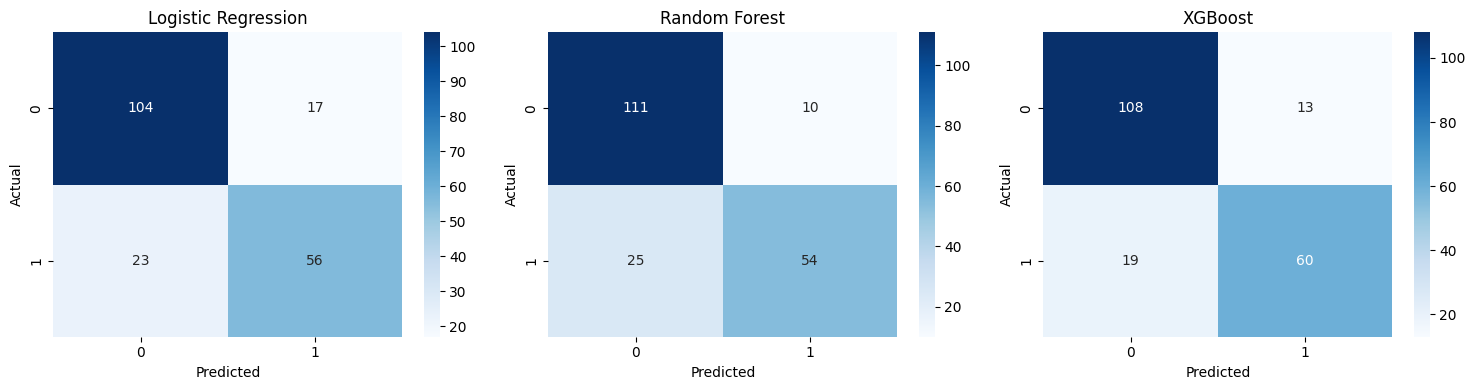

In [ ]:
# 2. Confusion Matrices

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(15, 4))

for i, (name, model) in enumerate(models.items(), 1):
    plt.subplot(1, len(models), i)

    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()

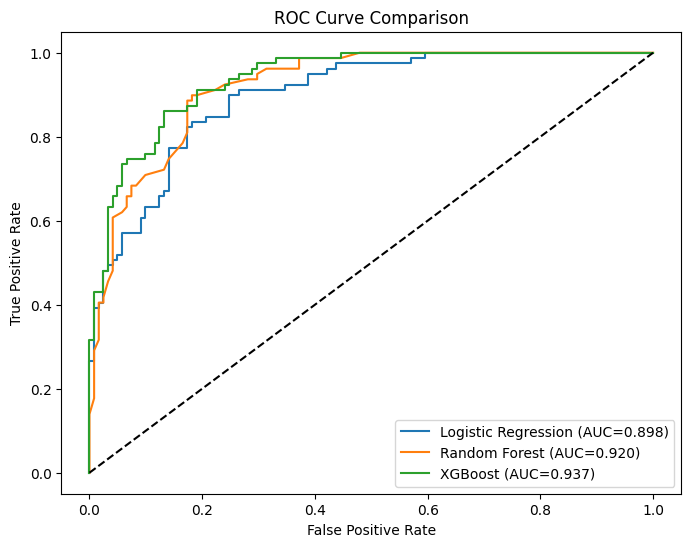

In [ ]:
# 3. ROC Curves
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8,6))

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)

    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

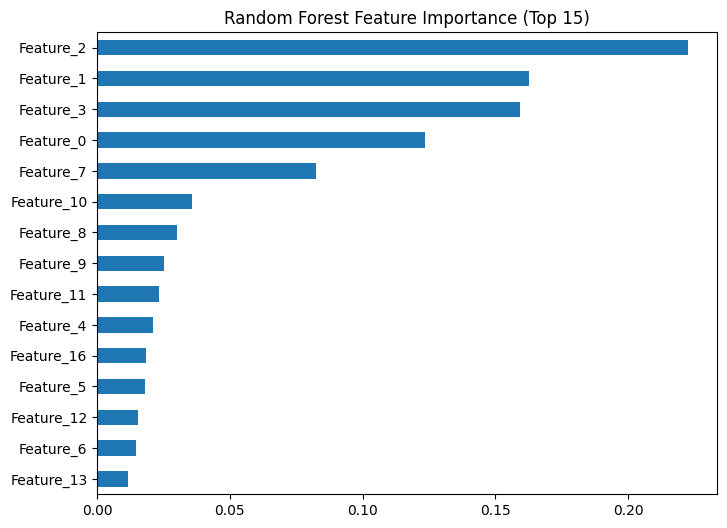

In [ ]:
# 4. Feature importance plots (Random Forest)

import pandas as pd

feature_names = [f"Feature_{i}" for i in range(X_train.shape[1])]

rf_importance = pd.Series(rf_model.feature_importances_, index=feature_names)
rf_importance.sort_values(ascending=False).head(15).plot(kind='barh', figsize=(8,6))
plt.title("Random Forest Feature Importance (Top 15)")
plt.gca().invert_yaxis()
plt.show()

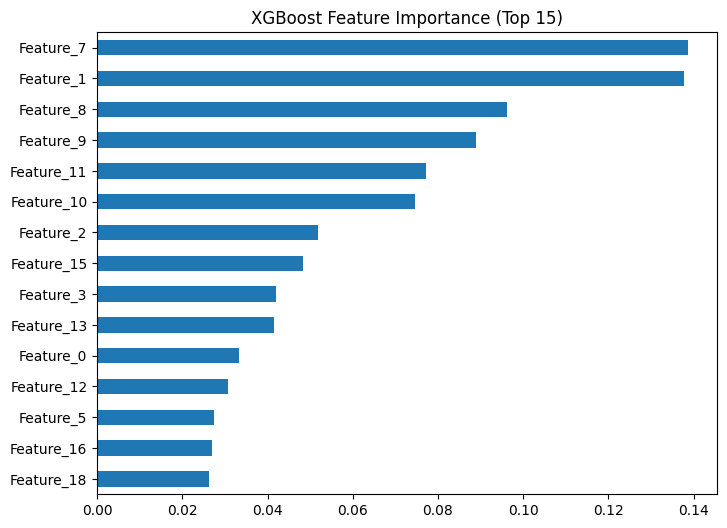

In [ ]:
#(For XGBoost)

xgb_importance = pd.Series(xgb_model.feature_importances_, index=feature_names)
xgb_importance.sort_values(ascending=False).head(15).plot(kind='barh', figsize=(8,6))
plt.title("XGBoost Feature Importance (Top 15)")
plt.gca().invert_yaxis()
plt.show()

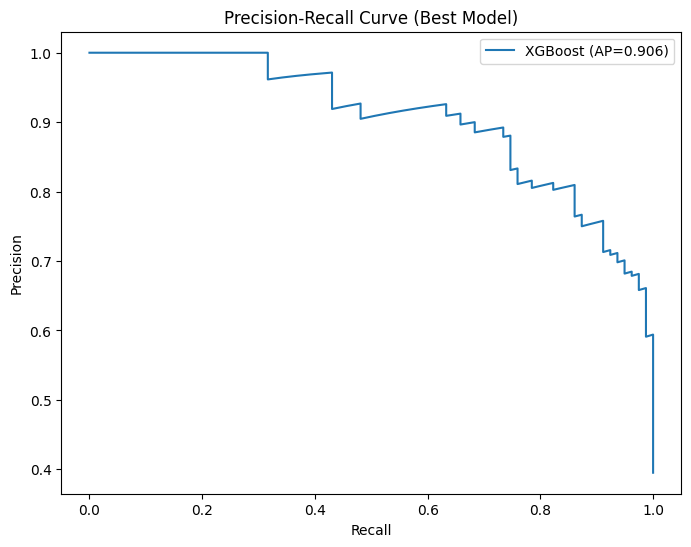

In [ ]:
# 5. Precision-Recall curve for best model

from sklearn.metrics import precision_recall_curve, average_precision_score

best_model_name = summary_df.iloc[0]["Model"]
best_model = models[best_model_name]

y_proba = best_model.predict_proba(X_test)[:, 1]
precision, recall, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f"{best_model_name} (AP={ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Best Model)")
plt.legend()
plt.show()

In [ ]:
# 3.3
# 1. For a credit risk classification problem, Recall (on the "bad"/default class) is the most important metric.
#   In this business context, failing to detect a high-risk borrower (False Negative) results in financial loss due to loan default. Therefore, maximizing recall ensures that most risky applicants are correctly flagged.
#   While accuracy may appear high, it can be misleading in imbalanced datasets where “good” borrowers dominate. Hence, recall and F1-score are more reliable metrics.



# 2. False Negative (Very Costly)
#   Predicting a borrower as "good" when they are actually "bad" results in loan default and direct financial loss.

#   False Positive (Moderate Cost)
#   Predicting a borrower as "bad" when they are actually "good" results in rejecting a potentially profitable customer.

#   From a financial risk perspective:
#   False Negatives are significantly more costly than False Positives.

#  Therefore, the model should prioritize minimizing False Negatives (i.e., maximize recall).



# 3. The assignment specifies a recall ≥ 75% on defaults.

# Given business risk considerations, I recommend:
# Recall between 75%–85%

# This ensures:
# Most high-risk applicants are detected
# False negatives are minimized
# Acceptable trade-off with precision
# Threshold tuning can be performed using the Precision–Recall curve to select a cutoff that satisfies business constraints.

3.4

Recommended Model: XGBoost

XGBoost is recommended for production deployment based on the following criteria:

1. Performance

XGBoost achieved the strongest overall performance across evaluation metrics, including high AUC-ROC and F1-score. Most importantly, it maintains recall ≥ 75% for the default class, ensuring that the majority of high-risk customers are correctly identified. Since missing defaulters leads to direct financial loss, strong recall makes this model suitable for deployment.

2. Interpretability (Regulatory Compliance)

Although more complex than Logistic Regression, interpretability can be achieved using:

Feature importance analysis

SHAP (SHapley Additive Explanations) values

These tools allow individual prediction explanations, ensuring transparency and compliance with financial regulations.

3. Inference Speed

XGBoost is optimized for fast prediction on structured tabular data. It supports low-latency inference, making it suitable for real-time credit scoring systems.

4. Maintenance Complexity

While slightly more complex than simpler models, XGBoost remains stable once tuned. With proper version control and monitoring, maintenance complexity is manageable and justified by its superior performance.

Deployment Plan (XGBoost Credit Risk Model)
1. Infrastructure

Train model in development environment.

Serialize final XGBoost model using joblib.

Containerize using Docker.

Deploy on:

AWS EC2 / GCP / Azure VM

Or managed service like AWS SageMaker

Use CI/CD pipeline for version-controlled deployments.

2. API Design

Build REST API using FastAPI or Flask.

Endpoint:
POST /predict

Input: Customer features (JSON format).

Output:

Default probability

Final classification (Default / Non-Default)

Explanation (optional SHAP values)

Example response:

{
  "default_probability": 0.82,
  "prediction": "High Risk"
}
3. Preprocessing Pipeline

Save preprocessing steps (encoding, scaling) using Pipeline.

Ensure:

Same feature order

Same encoders

Same scaling parameters

Never re-fit preprocessing in production.

4. Input Validation

Validate:

Missing fields

Data types

Allowed value ranges

Reject invalid requests.

Log all requests for audit tracking.

5. Performance Monitoring

Monitor daily:

Recall on default class

Approval rate

Average predicted probability

Confusion matrix trends

Set alert if recall drops below 75%.

6. Data Drift Detection

Use PSI (Population Stability Index).

Compare production feature distribution with training data.

Trigger retraining if drift exceeds threshold (e.g., PSI > 0.2).

7. Retraining Strategy

Retrain quarterly OR

Retrain when:

Recall drops significantly

Business policy changes

Major data drift detected

Maintain model versioning.

8. A/B Testing Strategy

Deploy XGBoost to 20% traffic.

Compare against baseline model.

Measure:

Default rate

Profitability

Approval rate

Roll out fully if performance improves.